# EDA & Tiền xử lý — Superconductivity (`Superconductivity/train.csv`)

Bài toán **hồi quy**: dự đoán `critical_temp` (nhiệt độ tới hạn). **81 feature, toàn số, 0 missing** —
một bộ "sạch" lý tưởng để thực nghiệm **feature selection** (đặc biệt có **đa cộng tuyến rất nặng** vì feature là
các thống kê dẫn xuất: mean/wtd_mean/gmean/entropy/range/std... của cùng nhóm tính chất nguyên tố).

> ⚠️ Target `critical_temp` giữ **nguyên gốc**, chỉ xử lý feature.
> Bộ còn có `unique_m.csv` (biểu diễn theo **tỉ lệ nguyên tố** + cột chuỗi `material`) — notebook này tập trung vào `train.csv`.

## 0. Thiết lập môi trường
> Chạy local thì bỏ phần `drive`/`os.chdir`. Cần `train.csv` trong thư mục làm việc.

In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/AIO-Conquer02')
os.getcwd()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/AIO-Conquer02'

## 1. Nạp & kiểm tra tổng quan
**Lý do:** `info()` để nắm kích thước, kiểu dữ liệu, mức độ đầy đủ.

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('Superconductivity/train.csv')
print('Shape:', df.shape, '| Target:', df.columns[-1])
df.info(verbose=False)

Shape: (21263, 82) | Target: critical_temp
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Columns: 82 entries, number_of_elements to critical_temp
dtypes: float64(79), int64(3)
memory usage: 13.3 MB


> 📊 **Phân tích:** **21.263 dòng × 82 cột** (81 feature + target `critical_temp`), **toàn `float/int`, 0 cột chữ**.
> Feature là các thống kê tổng hợp từ thành phần nguyên tố (atomic_mass, fie, atomic_radius, density, ElectronAffinity,
> ThermalConductivity, Valence...) theo nhiều phép gộp khác nhau.

## 2. Missing & dòng trùng
**Lý do:** Xác nhận không thiếu; đếm dòng trùng (vài công thức vật liệu có thể lặp).

In [3]:
print('Tổng ô missing:', int(df.isna().sum().sum()))
print('Số dòng trùng hoàn toàn:', int(df.duplicated().sum()))

Tổng ô missing: 0
Số dòng trùng hoàn toàn: 66


> 📊 **Phân tích:** **0 missing** → không cần impute. Có **66 dòng trùng hoàn toàn** → bỏ để tránh thiên lệch / rò rỉ train-test.

## 3. Cleaning — bỏ dòng trùng
**Lý do:** Loại 66 dòng trùng, giữ nguyên mọi cột.

In [4]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Đã bỏ {before - len(df)} dòng trùng | còn {len(df)} dòng')

Đã bỏ 66 dòng trùng | còn 21197 dòng


## 4. Phân phối target & độ lệch feature
**Lý do:** Xem hình dạng target và feature nào lệch mạnh.

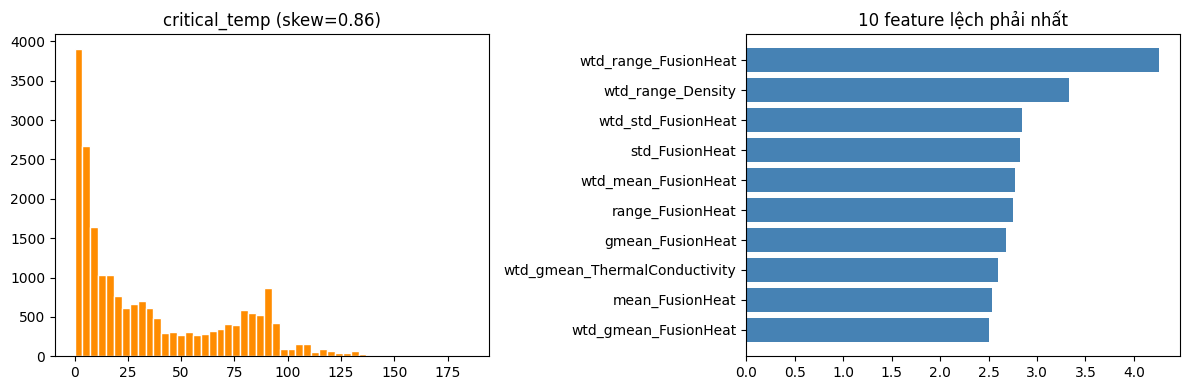

In [5]:
TARGET = 'critical_temp'
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df[TARGET], bins=50, color='darkorange', edgecolor='white')
ax[0].set_title(f'{TARGET} (skew={df[TARGET].skew():.2f})')
sk = df.drop(columns=[TARGET]).skew().sort_values(ascending=False)
ax[1].barh(sk.index[:10][::-1], sk.values[:10][::-1], color='steelblue')
ax[1].set_title('10 feature lệch phải nhất'); plt.tight_layout(); plt.show()

> 📊 **Phân tích:** Target `critical_temp` (0–185 K) **lệch phải nhẹ** (skew ~0,86) — đa số vật liệu nhiệt độ tới hạn thấp.
> Độ lệch feature trải rộng (≈ −0,9 đến 4,2); một số feature dạng `range_`/`std_` lệch phải → cân nhắc log/scale ở model tuyến tính.

## 5. Đa cộng tuyến — heatmap (mẫu) & đếm cặp tương quan cao
**Lý do:** 81 feature là thống kê dẫn xuất nên trùng lặp thông tin nhiều; đếm số cặp |r|>0.9 để định lượng.

Số cặp feature |r| > 0.9: 74


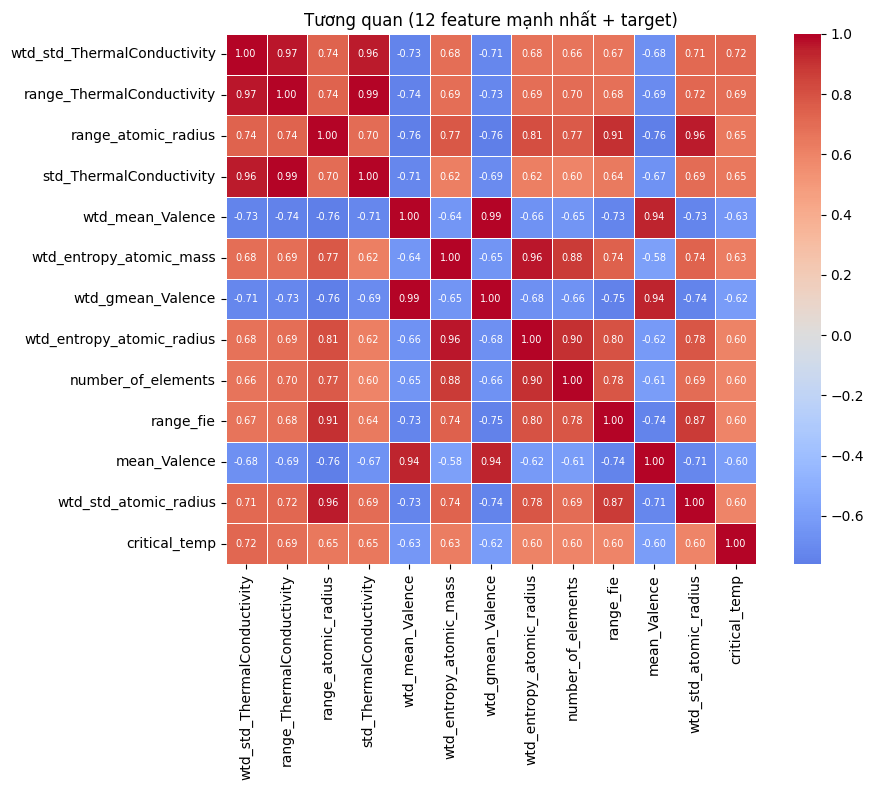

In [6]:
import seaborn as sns
corr = df.drop(columns=[TARGET]).corr().abs()
mask = np.triu(np.ones(corr.shape), 1).astype(bool)
n_hi = int((corr.where(mask) > 0.9).sum().sum())
print('Số cặp feature |r| > 0.9:', n_hi)

# heatmap trên 12 feature tương quan mạnh nhất với target cho dễ nhìn
top_feats = df.corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(12).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_feats + [TARGET]].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=.4, annot_kws={'size': 7})
plt.title('Tương quan (12 feature mạnh nhất + target)'); plt.tight_layout(); plt.show()

> 📊 **Phân tích:** **~74 cặp feature có |r|>0,9** — đa cộng tuyến **rất nặng** (các phép gộp mean/wtd_mean/gmean của cùng
> tính chất gần như trùng nhau). → với Linear Regression, hệ số sẽ **bất ổn**; đây chính là chỗ feature selection (Lasso/RFE)
> hoặc PCA giúp ích, nhưng cũng khiến selection **kém ổn định** (chọn đại 1 trong nhóm trùng).

## 6. Tương quan với target
**Lý do:** Xếp hạng |Pearson| để biết nhóm tính chất nào quyết định nhiệt độ tới hạn.

Top 10 |corr| mạnh nhất:
wtd_std_ThermalConductivity    0.721
range_ThermalConductivity      0.687
range_atomic_radius            0.653
std_ThermalConductivity        0.653
wtd_mean_Valence              -0.632
wtd_entropy_atomic_mass        0.627
wtd_gmean_Valence             -0.615
wtd_entropy_atomic_radius      0.603
number_of_elements             0.600
range_fie                      0.600
Name: critical_temp, dtype: float64

Số feature |corr| < 0.1: 2 / 81


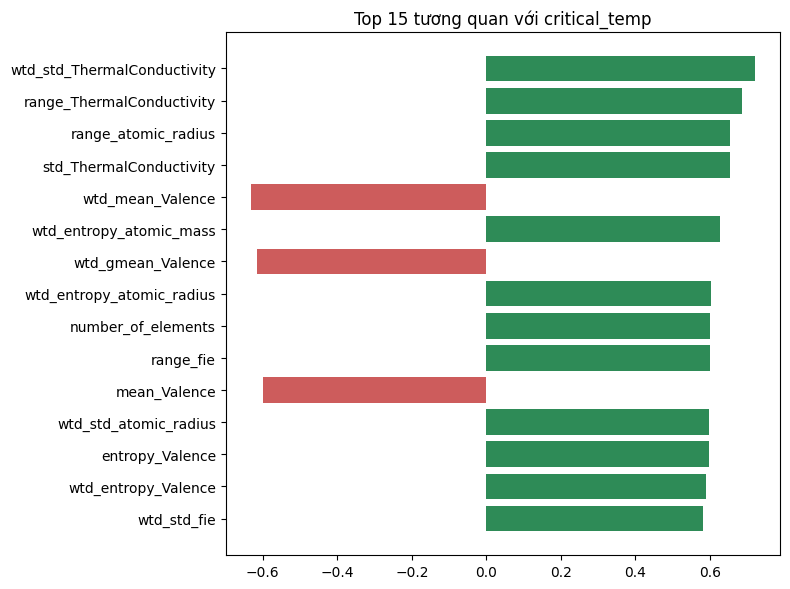

In [7]:
corr_t = df.corr()[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False)
print('Top 10 |corr| mạnh nhất:')
print(corr_t.head(10).round(3))
print('\nSố feature |corr| < 0.1:', int((corr_t.abs() < 0.1).sum()), '/', len(corr_t))
plt.figure(figsize=(8, 6))
top = corr_t.head(15)
plt.barh(top.index[::-1], top.values[::-1], color=['seagreen' if v>0 else 'indianred' for v in top.values[::-1]])
plt.title('Top 15 tương quan với critical_temp'); plt.tight_layout(); plt.show()

> 📊 **Phân tích:** Mạnh nhất: **`wtd_std_ThermalConductivity` (0,72)**, `range_ThermalConductivity` (0,69),
> `range_atomic_radius` (0,65), `wtd_mean_Valence` (0,63). **25/81 feature có |corr|>0,5** (nhiều tín hiệu mạnh) và
> chỉ ~2 feature gần nhiễu → khác Communities ở chỗ đây là bài toán **đa cộng tuyến** hơn là **nhiều nhiễu**.

## 7. Lưu dữ liệu đã xử lý
**Lý do:** Bỏ 66 dòng trùng, giữ nguyên 81 feature + target. Lưu `superconductivity_processed.csv`.

In [8]:
df.to_csv('superconductivity_processed.csv', index=False)
print('Đã lưu superconductivity_processed.csv |', df.shape, '| missing:', int(df.isna().sum().sum()))
df.head()

Đã lưu superconductivity_processed.csv | (21197, 82) | missing: 0


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


> 💾 **Kết quả:** `superconductivity_processed.csv` — **21.197 × 82** (81 feature + target), 0 missing, target nguyên gốc.
>
> **Sẵn cho thí nghiệm selection:** 81 feature số, **đa cộng tuyến nặng** → so sánh **Linear Regression full vs Lasso vs RFE**.
> Nhớ **`StandardScaler`** trước Lasso (feature ở thang khác nhau). Cặp này bổ trợ Communities: một bên *nhiều nhiễu*, một bên *nhiều trùng lặp*.